In [2]:
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split
from sklearn.datasets import make_circles
import matplotlib.pyplot as plt
import numpy as np


In [3]:
# Helper: plot decision boundary + margins
def plot_decision_boundary(clf, X, y):
    plt.scatter(X[:, 0], X[:, 1], c=y, cmap='coolwarm', s=30)

    ax = plt.gca()
    xlim = ax.get_xlim()
    ylim = ax.get_ylim()

    xx, yy = np.meshgrid(
        np.linspace(xlim[0], xlim[1], 200),
        np.linspace(ylim[0], ylim[1], 200)
    )
    Z = clf.decision_function(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)

    # decision boundary and margins
    ax.contour(xx, yy, Z, colors='k',
               levels=[-1, 0, 1], linestyles=['--', '-', '--'])
    plt.show()


In [4]:
# --- Basic linear SVC ---
points, labels = make_circles(n_samples=100, factor=.3, noise=.05, random_state=42)
classifier = SVC(kernel="linear")
classifier.fit(points, labels)
print("Predictions:", classifier.predict([[3, 4], [6, 7]]))


Predictions: [1 1]


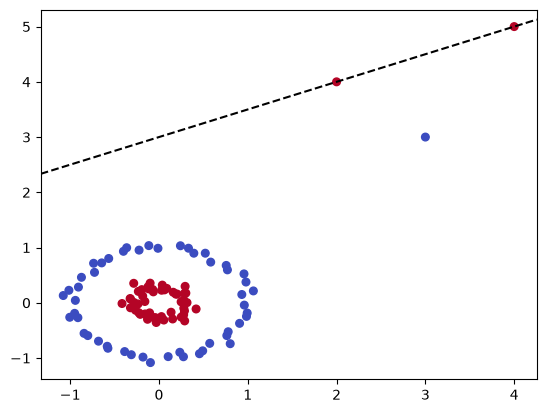

In [5]:
# --- Add points manually ---
points = np.vstack([points, [[3, 3], [2, 4], [4, 5]]])
labels = np.hstack([labels, [0, 1, 1]])

classifier = SVC(kernel='linear', C=0.1)
classifier.fit(points, labels)
plot_decision_boundary(classifier, points, labels)


In [6]:
# --- Polynomial kernel ---
X_train, X_val, y_train, y_val = train_test_split(
    points, labels, train_size=0.8, test_size=0.2, random_state=100
)
classifier = SVC(kernel='poly')
classifier.fit(X_train, y_train)
print("Poly kernel score:", classifier.score(X_val, y_val))


Poly kernel score: 0.38095238095238093


In [7]:
# --- Concentric circles dataset ---
points, labels = make_circles(n_samples=300, factor=.2, noise=.05, random_state=1)
X_train, X_val, y_train, y_val = train_test_split(
    points, labels, train_size=0.8, test_size=0.2, random_state=100
)

classifier = SVC(kernel="linear", random_state=1)
classifier.fit(X_train, y_train)
print("Linear kernel score:", classifier.score(X_val, y_val))
print("First training sample:", X_train[0])


Linear kernel score: 0.5666666666666667
First training sample: [0.31860062 0.11705731]


In [8]:
# --- Manual feature transform ---
new_train = [[np.sqrt(2) * pt[0] * pt[1], pt[0] ** 2, pt[1] ** 2] for pt in X_train]
new_val = [[np.sqrt(2) * pt[0] * pt[1], pt[0] ** 2, pt[1] ** 2] for pt in X_val]

classifier.fit(new_train, y_train)
print("Manual transform score:", classifier.score(new_val, y_val))


Manual transform score: 1.0


In [9]:
# --- RBF kernel ---
X_train, X_val, y_train, y_val = train_test_split(
    points, labels, train_size=0.8, test_size=0.2, random_state=100
)
classifier = SVC(kernel="rbf", gamma=0.1)
classifier.fit(X_train, y_train)
print("RBF kernel score:", classifier.score(X_val, y_val))


RBF kernel score: 1.0
